In this problem, you will develop a model to predict whether a given
car gets high or low gas mileage based on the Auto data set.

In [46]:
from ISLP import load_data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

| 變數名稱 | 類型 | 意思 | 單位或範圍 | 備註 |
|-----------|------|------|-------------|------|
| **mpg** | 連續型 (float) | Miles per gallon — 每加侖油可行駛的英里數 | 約 9–46 | 油耗效率（數值越高越省油） |
| **cylinders** | 類別型 (int) | 汽缸數量 | 常見值：3, 4, 5, 6, 8 | 汽缸越多 → 引擎越大、越耗油 |
| **displacement** | 連續型 (float) | 引擎排氣量（立方英吋） | 約 68–455 | 引擎大小的衡量指標 |
| **horsepower** | 連續型 (float) | 馬力 | 約 46–230 | 引擎輸出的動力 |
| **weight** | 連續型 (float) | 車重（磅, pounds） | 約 1600–5000 | 重量越大通常越耗油 |
| **acceleration** | 連續型 (float) | 由 0 加速到 60 mph 所需秒數 | 約 8–24 秒 | 值越小代表加速越快 |
| **year** | 整數 (int) | 出廠年份 (modulo 1900) | 70–82 | 1970–1982 年製造 |
| **origin** | 類別型 (int) | 製造地區代碼 | 1 = 美國、2 = 歐洲、3 = 日本 | 地區與車款特性有關 |
| **name** | 字串 (string) | 車款名稱 | — | 例如 "ford pinto" |
| **mpg01** *(自建變數)* | 類別型 (int, 0/1) | 根據 `mpg` 是否高於中位數分類 | 0 = 高油耗（mpg 高）、1 = 低油耗（mpg 低） | 作為分類標籤（dependent variable） |


In [ ]:
df = load_data('Auto')
df.describe

<bound method NDFrame.describe of                             mpg  cylinders  displacement  horsepower  weight  \
name                                                                           
chevrolet chevelle malibu  18.0          8         307.0         130    3504   
buick skylark 320          15.0          8         350.0         165    3693   
plymouth satellite         18.0          8         318.0         150    3436   
amc rebel sst              16.0          8         304.0         150    3433   
ford torino                17.0          8         302.0         140    3449   
...                         ...        ...           ...         ...     ...   
ford mustang gl            27.0          4         140.0          86    2790   
vw pickup                  44.0          4          97.0          52    2130   
dodge rampage              32.0          4         135.0          84    2295   
ford ranger                28.0          4         120.0          79    2625   
chevy 

(a) Create a binary variable, mpg01, that contains a 1 if mpg contains
a value above its median, and a 0 if mpg contains a value below
its median. You can compute the median using the median()
method of the data frame. Note you may find it helpful to add
a column mpg01 to the data frame by assignment. Assuming you
have stored the data frame as Auto, this can be done as follows: Auto['mpg01'] = mpg01

In [13]:
median = df['mpg'].median()
df['mpg01'] = [0 if x > median else 1 for x in df['mpg']]

(b) Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other
features seem most likely to be useful in predicting mpg01? Scatterplots and boxplots may be useful tools to answer this question. Describe your findings.

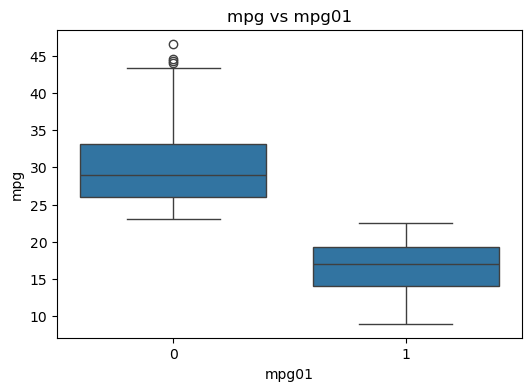

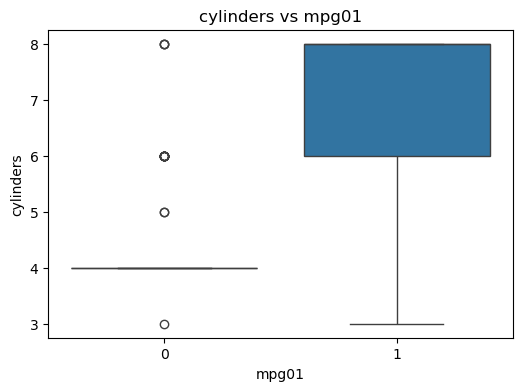

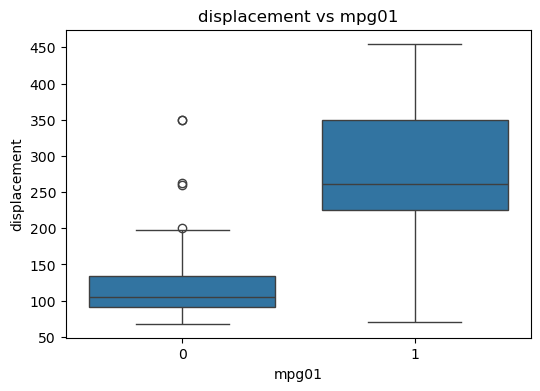

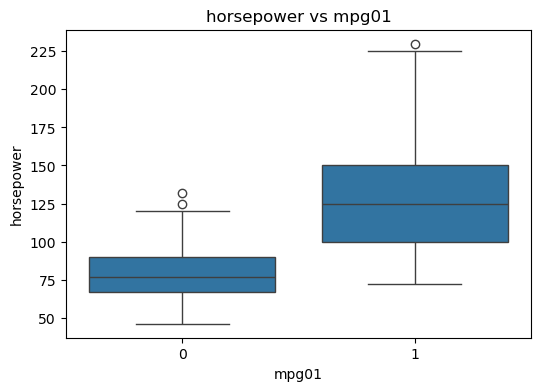

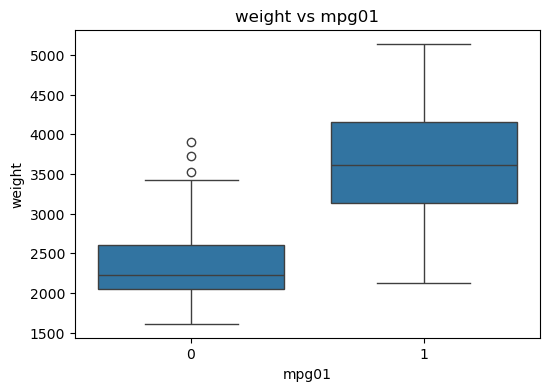

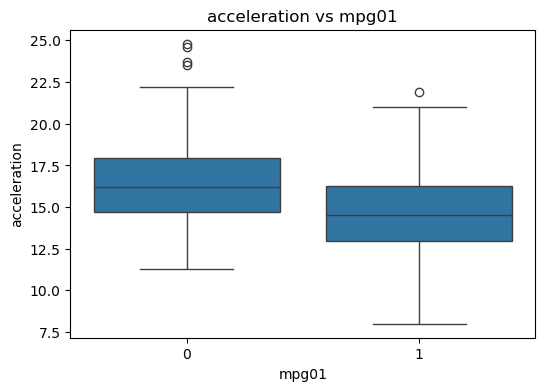

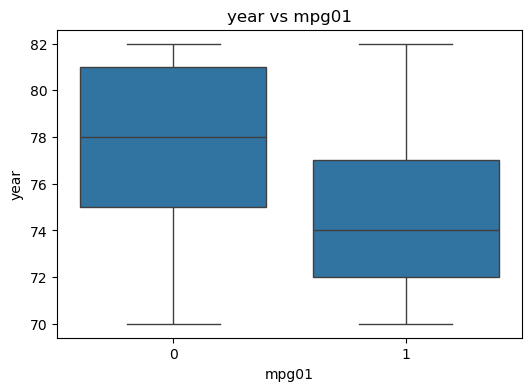

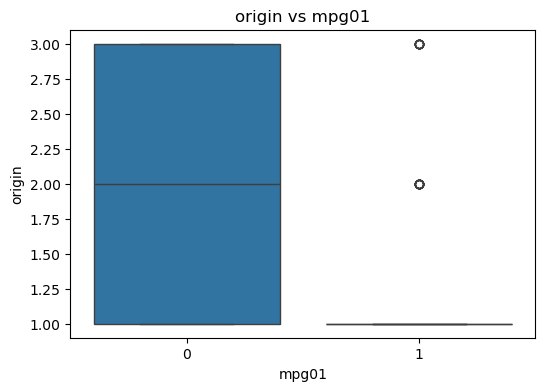

In [18]:
features = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']
for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='mpg01', y=feature, data=df)
    plt.title(f'{feature} vs mpg01')
    plt.show()

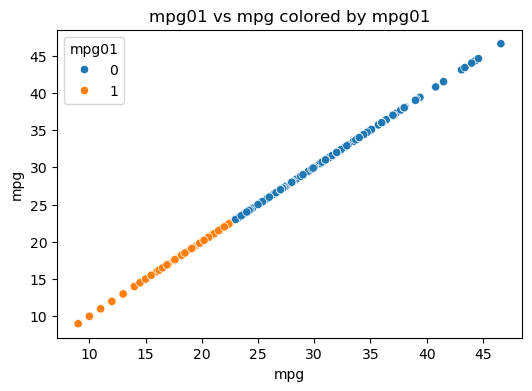

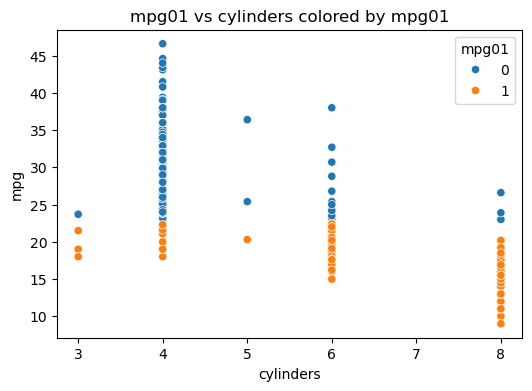

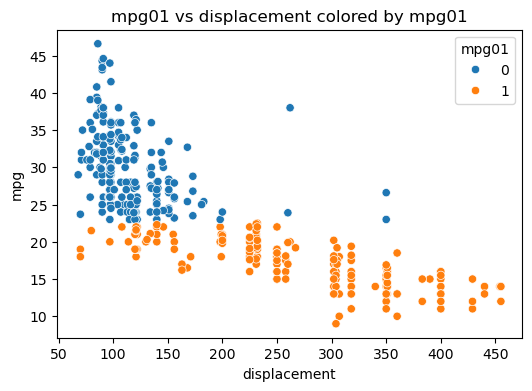

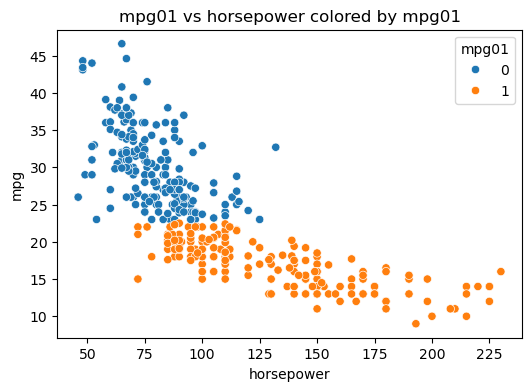

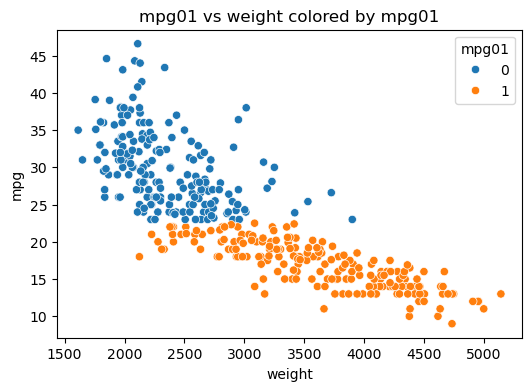

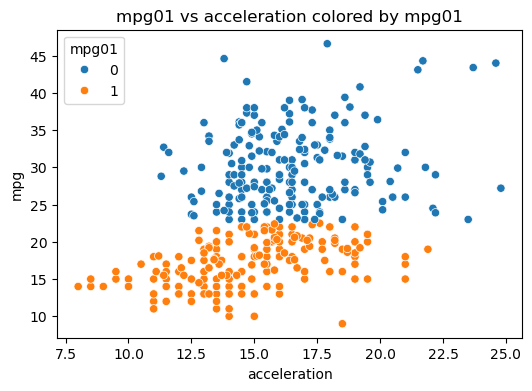

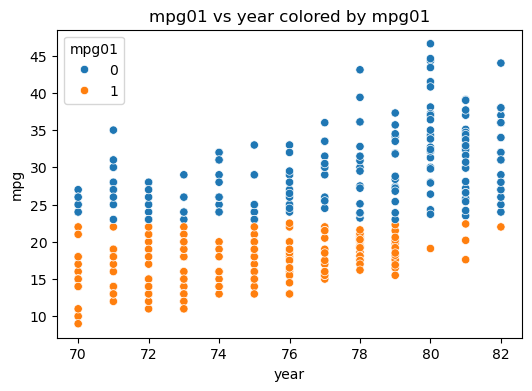

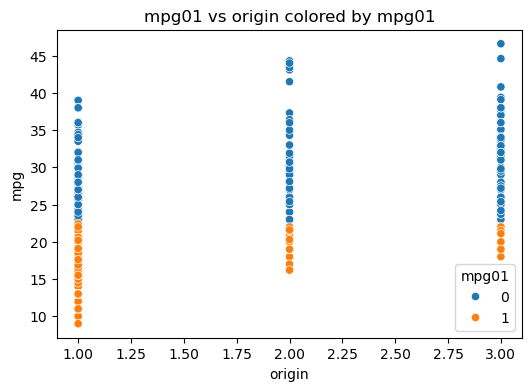

In [22]:
for feature in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(y='mpg', x=feature, hue='mpg01', data=df)
    plt.title(f'mpg01 vs {feature} colored by mpg01')
    plt.show()

Based on the boxplots and scatterplots, the variables cylinders, displacement, horsepower, and weight appear to be the most useful predictors of mpg01.

In the boxplots, the two groups of mpg01 show clearly separated boxes with little or no overlap along the y-axis, indicating strong differences in their distributions.

Similarly, the scatterplots reveal distinct clusters of points for the two categories, even though a few observations may still be misclassified due to overlap near the boundary.


(c) Split the data into a training set and a test set

In [33]:
X = df[['cylinders', 'displacement', 'horsepower', 'weight']]
y = df['mpg01']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

(d) Perform LDA on the training data in order to predict mpg01
using the variables that seemed most associated with mpg01 in
(b). What is the test error of the model obtained?

In [50]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred = lda.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

te = 1 - acc
print(f"Test error: {te:.3f}")
print("Confusion matrix:")
print(f"                  Predicted 0         Predicted 1")
print(f"Actual 0         {cm[0,0]:>6}             {cm[0,1]:>6}")
print(f"Actual 1         {cm[1,0]:>6}             {cm[1,1]:>6}")


Test error: 0.085
Confusion matrix:
                  Predicted 0         Predicted 1
Actual 0             50                  3
Actual 1              7                 58


(e) Perform QDA on the training data in order to predict mpg01
using the variables that seemed most associated with mpg01 in
(b). What is the test error of the model obtained?

In [49]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

y_pred = qda.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

te = 1 - acc
print(f"Test error: {te:.3f}")
print("Confusion matrix:")
print(f"                  Predicted 0         Predicted 1")
print(f"Actual 0         {cm[0,0]:>6}             {cm[0,1]:>6}")
print(f"Actual 1         {cm[1,0]:>6}             {cm[1,1]:>6}")

Test error: 0.076
Confusion matrix:
                  Predicted 0         Predicted 1
Actual 0             48                  5
Actual 1              4                 61


(f) Perform logistic regression on the training data in order to pre-
dict mpg01 using the variables that seemed most associated with
mpg01 in (b). What is the test error of the model obtained?

In [48]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

te = 1 - acc
print(f"Test error: {te:.3f}")
print("Confusion matrix:")
print(f"                  Predicted 0         Predicted 1")
print(f"Actual 0         {cm[0,0]:>6}             {cm[0,1]:>6}")
print(f"Actual 1         {cm[1,0]:>6}             {cm[1,1]:>6}")

Test error: 0.085
Confusion matrix:
                  Predicted 0         Predicted 1
Actual 0             49                  4
Actual 1              6                 59


(g) Perform naive Bayes on the training data in order to predict
mpg01 using the variables that seemed most associated with mpg01
in (b). What is the test error of the model obtained?

In [47]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

te = 1 - acc
print(f"Test error: {te:.3f}")
print("Confusion matrix:")
print(f"                  Predicted 0         Predicted 1")
print(f"Actual 0         {cm[0,0]:>6}             {cm[0,1]:>6}")
print(f"Actual 1         {cm[1,0]:>6}             {cm[1,1]:>6}")

Test error: 0.085
Confusion matrix:
                  Predicted 0         Predicted 1
Actual 0             48                  5
Actual 1              5                 60


(h) Perform KNN on the training data, with several values of K, in
order to predict mpg01. Use only the variables that seemed most
associated with mpg01 in (b). What test errors do you obtain?
Which value of K seems to perform the best on this data set?

In [52]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    test_error = 1 - acc
    print(f"K={k}: Test error = {test_error:.3f}")
    print("Confusion matrix:")
    print(f"                  Predicted 0         Predicted 1")
    print(f"Actual 0         {cm[0,0]:>6}             {cm[0,1]:>6}")
    print(f"Actual 1         {cm[1,0]:>6}             {cm[1,1]:>6}")
    print("------------------------------------------------------")

K=1: Test error = 0.119
Confusion matrix:
                  Predicted 0         Predicted 1
Actual 0             47                  6
Actual 1              8                 57
------------------------------------------------------
K=2: Test error = 0.136
Confusion matrix:
                  Predicted 0         Predicted 1
Actual 0             47                  6
Actual 1             10                 55
------------------------------------------------------
K=3: Test error = 0.102
Confusion matrix:
                  Predicted 0         Predicted 1
Actual 0             47                  6
Actual 1              6                 59
------------------------------------------------------
K=4: Test error = 0.076
Confusion matrix:
                  Predicted 0         Predicted 1
Actual 0             50                  3
Actual 1              6                 59
------------------------------------------------------
K=5: Test error = 0.085
Confusion matrix:
                  Predicte

It seems that when K >= 6, they have the same error rate, which is lower than K = 1 ~ 5, indicating that they perform the best on this data set.